In [ ]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Conv2D,MaxPooling2D,Dense,Flatten,Dropout

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data() #10 differnet classes #small version of alexnet dataset(contains 1000 diff object categories)

In [ ]:
x_train.shape,x_test.shape

((50000, 32, 32, 3), (10000, 32, 32, 3))

((50000, 32, 32, 3), (10000, 32, 32, 3))

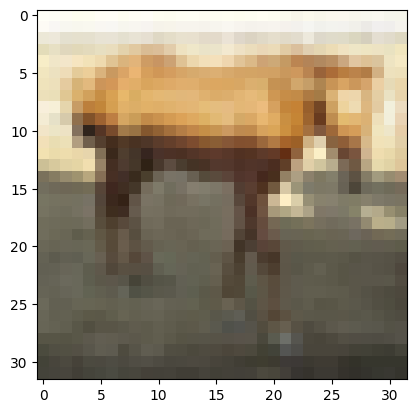

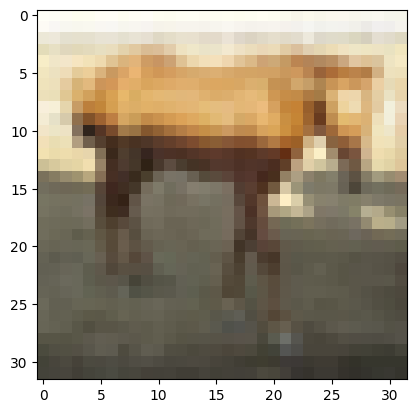

In [ ]:
#Let's try to Visualize it

from matplotlib import pyplot as plt
plt.imshow(x_train[2000])

In [ ]:
y_train[2000]     # 7th label -which is Horse

array([7], dtype=uint8)

array([7], dtype=uint8)

In [ ]:
model = Sequential()

#Covolutional_Layer_1
model.add(Conv2D(input_shape=(32,32,3),filters=96,kernel_size=(11,11),strides=(4,4),padding='same',activation='relu')) #we cant take input as (227,227,3) its so large.so we take like(32,32,3)
model.add(MaxPooling2D(pool_size=(3,3),strides=(2,2),padding="same"))                                                 #so padding also we give as 'same' instead of 'valid'

#Covolutional_Layer_2
model.add(Conv2D(filters=256,kernel_size=(5,5),strides=(1,1),padding='same',activation='relu'))
model.add(MaxPooling2D(pool_size=(3,3),strides=(2,2),padding="same"))

#Covolutional_Layer_3
model.add(Conv2D(filters=384,kernel_size=(3,3),strides=(1,1),padding='same',activation='relu'))

#Covolutional_Layer_4
model.add(Conv2D(filters=384,kernel_size=(3,3),strides=(1,1),padding='same',activation='relu'))

#Covolutional_Layer_5
model.add(Conv2D(filters=256,kernel_size=(3,3),strides=(1,1),padding='same',activation='relu'))
model.add(MaxPooling2D(pool_size=(3,3),strides=(2,2),padding="same"))

#Flatten_Layer
model.add(Flatten())

#Hidden_Layer_1
model.add(Dense(units=4096,activation="relu"))
model.add(Dropout(0.30))

#Hidden_Layer_2
model.add(Dense(units=4096,activation="relu"))
model.add(Dropout(0.30))

#Output_Layer
model.add(Dense(units=10,activation="softmax"))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 8, 8, 96)       │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 4, 4, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 4, 4, 256)      │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 2, 2, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 2, 2, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 2, 2, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │     1,052,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,622,154 (82.48 MB)

 Trainable params: 21,622,154 (82.48 MB)

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 96)       │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 256)      │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 2, 2, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 2, 2, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 2, 2, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4096)           │     1,052,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,622,154 (82.48 MB)

 Trainable params: 21,622,154 (82.48 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Totally we got a 8 Trainable layers

In [ ]:
model.compile(optimizer="sgd", loss="sparse_categorical_crossentropy" ,metrics=["sparse_categorical_accuracy"])  #Output is in the form of Numerical

In [ ]:
model_train = model.fit(x=x_train,y=y_train, epochs= 2, verbose = "auto", validation_data=(x_test,y_test))

Epoch 1/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 992s 634ms/step - loss: 1.9651 - sparse_categorical_accuracy: 0.2757 - val_loss: 1.6554 - val_sparse_categorical_accuracy: 0.4113
Epoch 2/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 969s 587ms/step - loss: 1.5580 - sparse_categorical_accuracy: 0.4406 - val_loss: 1.5171 - val_sparse_categorical_accuracy: 0.4465


In [ ]:
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - loss: 1.5171 - sparse_categorical_accuracy: 0.4465


[1.5170772075653076, 0.4465000033378601]

In [ ]:
pred= model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step


In [ ]:
import numpy as np

In [ ]:
np.argmax(pred[0])

np.int64(2)

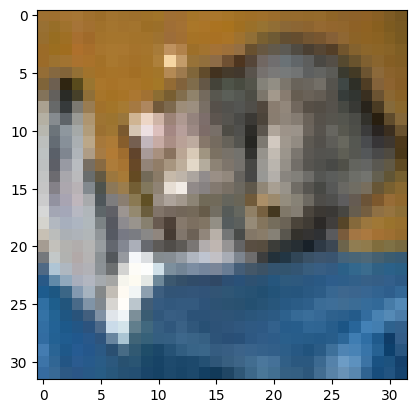

In [ ]:
plt.imshow(x_test[0])

In [ ]:
y_test[0]     # in 0th label= cat

array([3], dtype=uint8)

# Normalization

In [ ]:
#Normalize the x_train and x_test

x_train = x_train/255
x_test  = x_test/255

In [ ]:
x_test[0]

array([[[0.61960784, 0.43921569, 0.19215686],
        [0.62352941, 0.43529412, 0.18431373],
        [0.64705882, 0.45490196, 0.2       ],
        ...,
        [0.5372549 , 0.37254902, 0.14117647],
        [0.49411765, 0.35686275, 0.14117647],
        [0.45490196, 0.33333333, 0.12941176]],

       [[0.59607843, 0.43921569, 0.2       ],
        [0.59215686, 0.43137255, 0.15686275],
        [0.62352941, 0.44705882, 0.17647059],
        ...,
        [0.53333333, 0.37254902, 0.12156863],
        [0.49019608, 0.35686275, 0.1254902 ],
        [0.46666667, 0.34509804, 0.13333333]],

       [[0.59215686, 0.43137255, 0.18431373],
        [0.59215686, 0.42745098, 0.12941176],
        [0.61960784, 0.43529412, 0.14117647],
        ...,
        [0.54509804, 0.38431373, 0.13333333],
        [0.50980392, 0.37254902, 0.13333333],
        [0.47058824, 0.34901961, 0.12941176]],

       ...,

       [[0.26666667, 0.48627451, 0.69411765],
        [0.16470588, 0.39215686, 0.58039216],
        [0.12156863, 0

In [ ]:
model_train_normalize = model.fit(x=x_train,y=y_train, epochs= 2, verbose = "auto", validation_data=(x_test,y_test))

Epoch 1/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 939s 600ms/step - loss: 1.8469 - sparse_categorical_accuracy: 0.3272 - val_loss: 1.4828 - val_sparse_categorical_accuracy: 0.4581
Epoch 2/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 930s 595ms/step - loss: 1.4021 - sparse_categorical_accuracy: 0.4897 - val_loss: 1.3587 - val_sparse_categorical_accuracy: 0.5037
